# Framework de simulación y reconstrucción Single-Mask DF-DPC

Demostración del paquete **`sm_df_dpc`**: simulación de la toma de imágenes de rayos X
con máscara única y reconstrucción single-shot de **atenuación**, **fase diferencial (DPC)**
y **dark-field (DF)** para geometrías personalizables.

Basado en:

* J. Yuan & M. Das, *"Single-shot, single-mask X-ray dark-field and phase-contrast imaging"*,
  **Optica 12**, 1895 (2025) — `papers/optica-12-12-1895.pdf` / `papers/arxiv.pdf`.
* J. Yuan & M. Das, *"Transport-of-intensity model for single-mask x-ray DPC imaging"*,
  **Optica 11**, 478 (2024).

## 1. Modelo físico

El transporte se modela con la ecuación de **Fokker–Planck de rayos X** (Ec. 2 del paper):

$$ I(\vec r, z) = I(\vec r, 0) - \frac{z}{k}\nabla_\perp\cdot\left[I(\vec r,0)\nabla_\perp\varphi(\vec r,0)\right] + z\,S(\vec r)\,\nabla^2_\perp I(\vec r, 0), $$

con $I(\vec r, 0) = T(\vec r)\,M(x)$ (muestra × máscara). Integrando sobre cada píxel (Ec. 3) la
intensidad medida queda, en forma generalizada,

$$ I_n = T_n\left[(1-L_n)\,W_n - D_n\,A_n + S_n\,B_n\right], $$

donde los **coeficientes por píxel** se obtienen del perfil proyectado de la máscara
$m(x)$ (incluida la penumbra de la fuente):

$$ W_n = \tfrac1p\!\int_{pix}\! m\,dx, \qquad A_n = \tfrac1p\!\int_{pix}\! m'\,dx, \qquad B_n = \tfrac1p\!\int_{pix}\! m''\,dx, $$

y las señales de la muestra son $T_n$ (transmisión), $D_n = \tfrac{z}{k}\partial_x\varphi$
(desplazamiento del beamlet, µm), $L_n = \tfrac{z}{k}\nabla^2\varphi$ (fase Laplaciana) y
$S_n$ (varianza de ensanchamiento por USAXS, µm²).

## 2. Las tres configuraciones (mismo hardware)

| Config | Período proyectado | Alineamiento del beamlet | Señales |
|--------|--------------------|--------------------------|---------|
| DPC    | $2\,p_{det}$ ($M\approx2\times$) | frontera de píxel (uno de cada dos) | $T$, $D$ |
| DF     | $2\,p_{det}$ ($M\approx2\times$) | centro de píxel (uno de cada dos)   | $T$, $S$ |
| DF-DPC | $3\,p_{det}$ ($M\approx3\times$) | una de cada tres fronteras          | $T$, $D$, $S$ |

La condición de alineamiento (Moiré nulo) es $p_{mask}\cdot M = N\cdot p_{det}$.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # raíz del repo

import numpy as np
import matplotlib.pyplot as plt

from sm_df_dpc import (Geometry, Phantom, Cylinder, Slab, Sphere, Material,
                       material_library, SimConfig, simulate, retrieve,
                       mask_profile, compute_coefficients)

plt.rcParams['figure.dpi'] = 110

## 3. Geometría personalizable

`Geometry` encapsula máscara, detector, fuente y distancias. Con `d_md_m=None` la distancia
máscara–detector se calcula automáticamente para cumplir la condición de Moiré nulo de la
configuración elegida (los valores por defecto reproducen el experimento del paper:
máscara de 53 µm con slit de 20 µm, detector de 55 µm, foco de 20 µm, 40 kV, d_sm = 60 cm).

In [2]:
for cfg in ('DPC', 'DF', 'DF-DPC'):
    g = Geometry(config=cfg, d_sm_m=0.60)
    print(g.summary())
    g.validate()           # chequeos físicos (penumbra, slit, Moiré)
    print('-' * 60)

geom = Geometry(config='DF-DPC', d_sm_m=0.60, focal_spot_um=20.0, energy_kev=40.0)

Configuración        : DPC  (N = 2)
d_sm / d_md / L      : 60.00 / 64.53 / 124.53 cm
Magnificación M      : 2.0755
p_mask / slit        : 53.0 / 20.0 µm (duty 0.38, T_oro 0.09)
p_det / p_eff        : 55.0 / 26.50 µm
Período proyectado   : 110.00 µm (objetivo 110.00 µm, desvío +0.000%)
z_eff                : 31.09 cm
Energía / k          : 40.0 keV / 2.027e+05 µm⁻¹
Foco / penumbra det. : 20.0 / 21.5 µm
Offset máscara       : 0.00 µm (canónico)
------------------------------------------------------------
Configuración        : DF  (N = 2)
d_sm / d_md / L      : 60.00 / 64.53 / 124.53 cm
Magnificación M      : 2.0755
p_mask / slit        : 53.0 / 20.0 µm (duty 0.38, T_oro 0.09)
p_det / p_eff        : 55.0 / 26.50 µm
Período proyectado   : 110.00 µm (objetivo 110.00 µm, desvío +0.000%)
z_eff                : 31.09 cm
Energía / k          : 40.0 keV / 2.027e+05 µm⁻¹
Foco / penumbra det. : 20.0 / 21.5 µm
Offset máscara       : 13.25 µm (canónico)
---------------------------------------------

/tmp/ipykernel_7068/2722446817.py:4: UserWarning: [ADVERTENCIA] slit (20.0 µm) > w_max (16.1 µm): la zona iluminada (63.0 µm) excede los 1 píxel(es) de diseño (55.0 µm): contraste reducido.
  g.validate()           # chequeos físicos (penumbra, slit, Moiré)


## 4. Perfil de máscara proyectado y coeficientes del modelo

El perfil $m(x)$ se evalúa en el plano de la muestra (coordenadas de Fresnel) con la penumbra
del foco. De él se calculan numéricamente $(W_n, A_n, B_n)$ y los escalares del paper
($w_e,\ \alpha_1,\ \alpha_2,\ \alpha_3$), válidos para cualquier slit/foco/offset.

w_e = 0.433   α1 = 0.318   α2 = -0.0425 µm⁻¹   α3 = 0.00294 µm⁻²
Sensibilidad DPC : 0.1435 por µm de desplazamiento
Sensibilidad DF  : 0.0092 por µm² de varianza


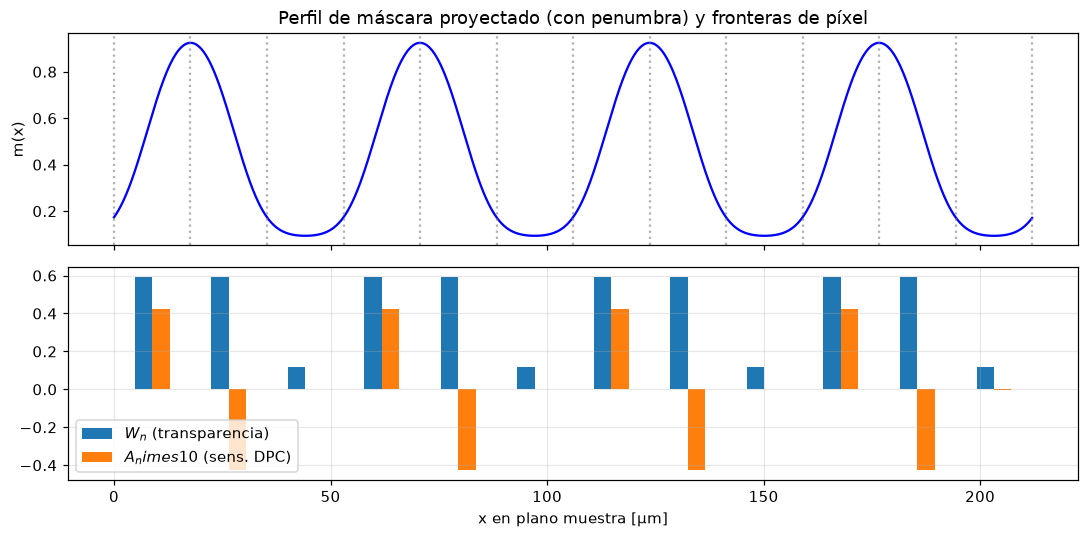

In [3]:
coef = compute_coefficients(geom, n_pix=12, oversample=128)
x = np.linspace(0, 12 * geom.p_eff_um, 2000)
m = mask_profile(geom, x)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(x, m, 'b-')
for j in range(13):
    axes[0].axvline(j * geom.p_eff_um, color='gray', ls=':', alpha=.6)
axes[0].set_ylabel('m(x)')
axes[0].set_title('Perfil de máscara proyectado (con penumbra) y fronteras de píxel')
xs = (np.arange(12) + 0.5) * geom.p_eff_um
axes[1].bar(xs - 2, coef.W, width=4, label='$W_n$ (transparencia)')
axes[1].bar(xs + 2, coef.A * 10, width=4, label="$A_n\times10$ (sens. DPC)")
axes[1].set_xlabel('x en plano muestra [µm]'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout()

print(f"w_e = {coef.we:.3f}   α1 = {coef.alpha1:.3f}   "
      f"α2 = {coef.alpha2:.4f} µm⁻¹   α3 = {coef.alpha3:.5f} µm⁻²")
print(f"Sensibilidad DPC : {coef.dpc_sensitivity:.4f} por µm de desplazamiento")
print(f"Sensibilidad DF  : {coef.df_sensitivity:.4f} por µm² de varianza")

## 5. Fantoma multi-material

Las formas (`Cylinder`, `Sphere`, `Slab`, `Wedge`, `CustomShape`) llevan un `Material` con
$\delta$ (fase), $\mu$ (atenuación) y un parámetro de microestructura USAXS [µrad²/µm] que
genera la señal dark-field. El fantoma imita al del paper: PMMA y tejido (solo fase/atenuación),
grafito (DF débil) y polvo de diamante (DF fuerte).

In [4]:
cfg = SimConfig(n_pix_x=900, n_rows=128, oversample=32,
                photons_per_pixel=1000, add_noise=True, seed=42,
                model='fokker_planck')   # o 'ray' para señales fuertes

fov_x = cfg.n_pix_x * geom.p_eff_um
fov_y = cfg.n_rows * geom.p_eff_um
mats = material_library(geom.energy_kev)

phantom = Phantom([
    Cylinder(mats['pmma'],     cx_um=0.18 * fov_x, radius_um=1100),
    Cylinder(mats['graphite'], cx_um=0.42 * fov_x, radius_um=1300),
    Slab(mats['diamond_powder'], 0.58 * fov_x, 0.76 * fov_x,
         thickness_um=900, taper_um=250),
    Sphere(mats['soft_tissue'], cx_um=0.88 * fov_x, cy_um=0.5 * fov_y,
           radius_um=0.42 * fov_y),
])

## 6. Simulación de la adquisición single-shot

`simulate` genera la imagen con muestra $I^{(S)}$ y la referencia solo-máscara $I^{(M)}$
(penumbra de la fuente + integración por píxel + ruido de Poisson) junto con las verdades
de terreno por píxel para validar.

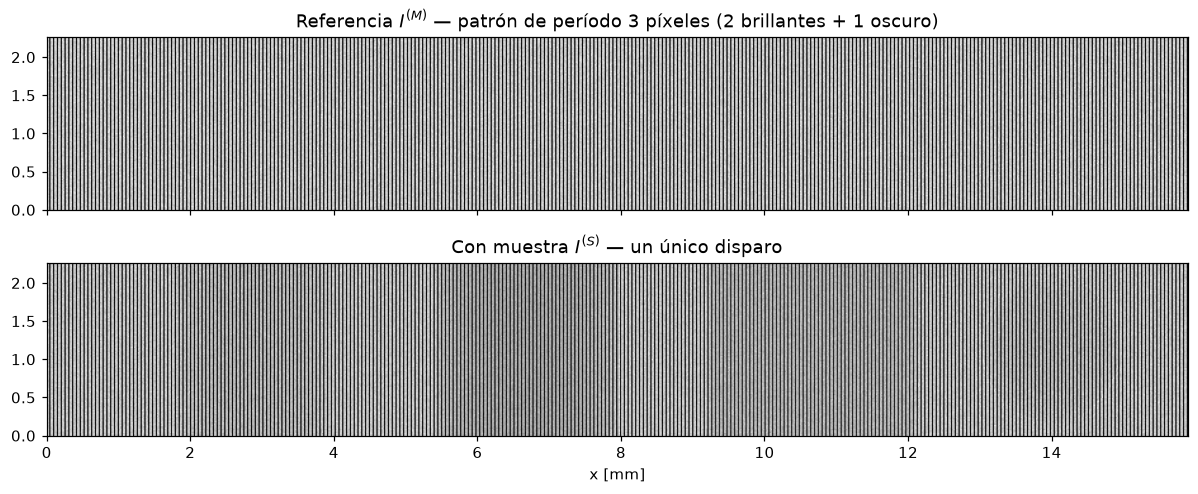

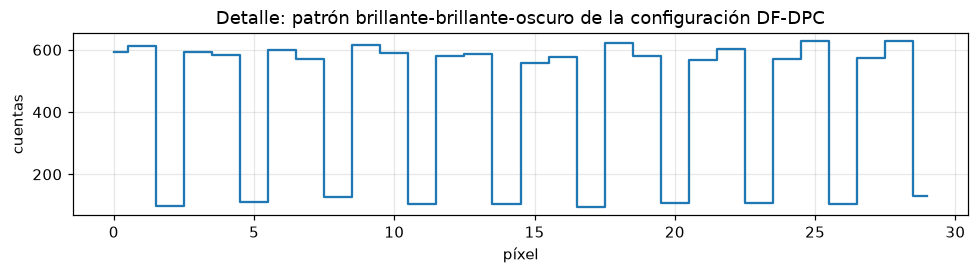

In [5]:
res = simulate(geom, phantom, cfg)
extent = [0, fov_x / 1000, 0, fov_y / 1000]

fig, axes = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True)
axes[0].imshow(res.I_mask, extent=extent, origin='lower', cmap='gray', aspect='auto')
axes[0].set_title('Referencia $I^{(M)}$ — patrón de período 3 píxeles (2 brillantes + 1 oscuro)')
axes[1].imshow(res.I_sample, extent=extent, origin='lower', cmap='gray', aspect='auto')
axes[1].set_title('Con muestra $I^{(S)}$ — un único disparo')
axes[1].set_xlabel('x [mm]')
plt.tight_layout()

# detalle del patrón de 3 píxeles
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.step(np.arange(30), res.I_mask[64, :30], where='mid')
ax.set_xlabel('píxel'); ax.set_ylabel('cuentas')
ax.set_title('Detalle: patrón brillante-brillante-oscuro de la configuración DF-DPC')
ax.grid(alpha=.3); plt.tight_layout()

## 7. Reconstrucción single-shot (Ec. 9 del paper)

`retrieve` devuelve las tres imágenes a partir del par $(I^{(S)}, I^{(M)})$:

* `transmission` — $T(1-L)$,
* `dpc_um` / `refraction_urad` — desplazamiento del beamlet $D_n$ y ángulo de refracción,
* `darkfield` / `Sn_um2` — señal adimensional del paper y varianza $S_n$.

`method='paper'` usa las fórmulas cerradas (Ecs. 5/7/9 generalizadas);
`method='lstsq'` ajusta el modelo lineal por grupos (robusto ante desalineamientos).

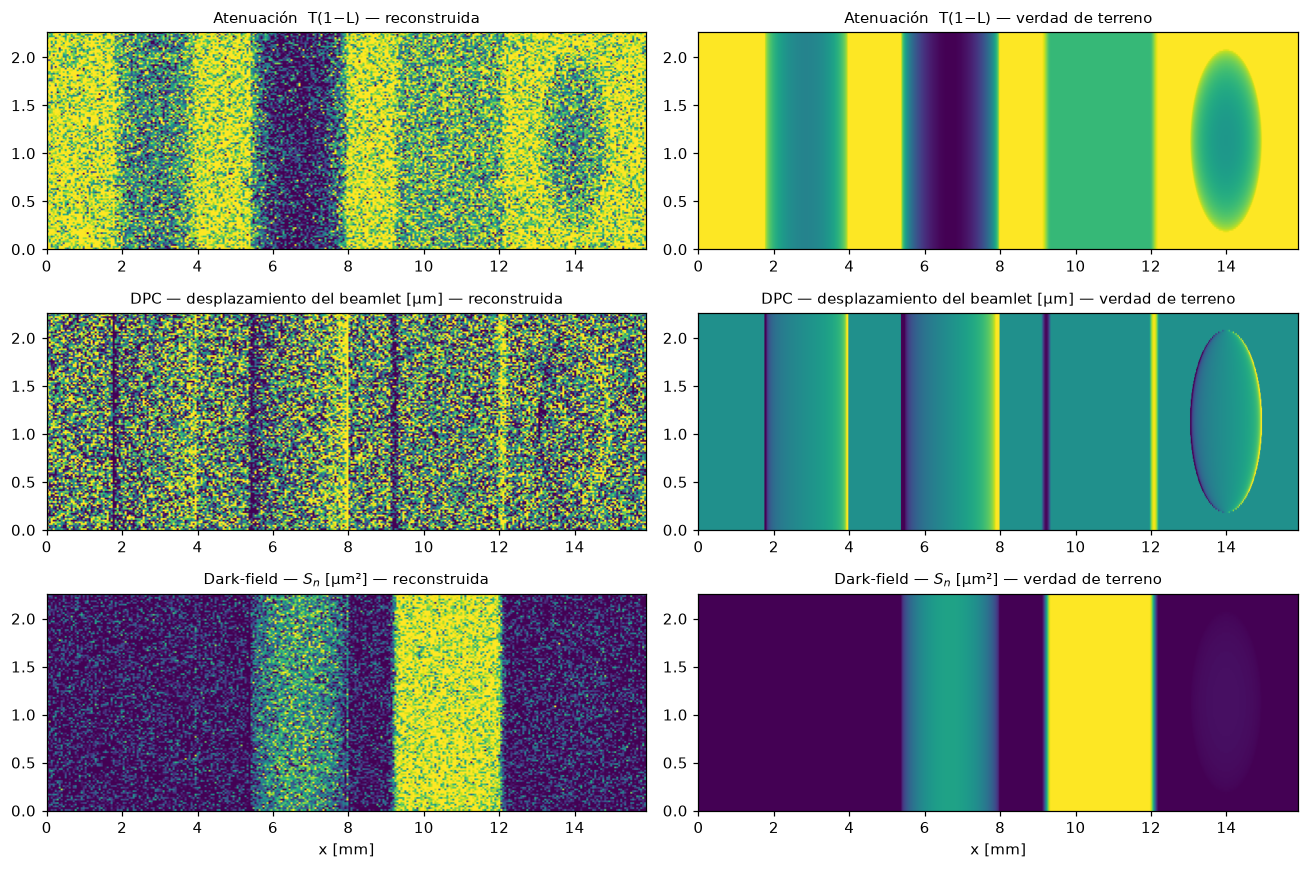

In [6]:
out = retrieve(res.I_sample, res.I_mask, geom, method='paper')

panels = [('transmission', 'T', 'Atenuación  T(1−L)'),
          ('dpc_um', 'D_um', 'DPC — desplazamiento del beamlet [µm]'),
          ('Sn_um2', 'Sn_um2', 'Dark-field — $S_n$ [µm²]')]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for i, (attr, key, title) in enumerate(panels):
    vmin, vmax = np.percentile(res.gt[key], [1, 99])
    axes[i, 0].imshow(getattr(out, attr), extent=extent, origin='lower',
                      aspect='auto', vmin=vmin, vmax=vmax)
    axes[i, 0].set_title(f'{title} — reconstruida', fontsize=10)
    axes[i, 1].imshow(res.gt[key], extent=extent, origin='lower',
                      aspect='auto', vmin=vmin, vmax=vmax)
    axes[i, 1].set_title(f'{title} — verdad de terreno', fontsize=10)
for ax in axes[-1]: ax.set_xlabel('x [mm]')
plt.tight_layout()

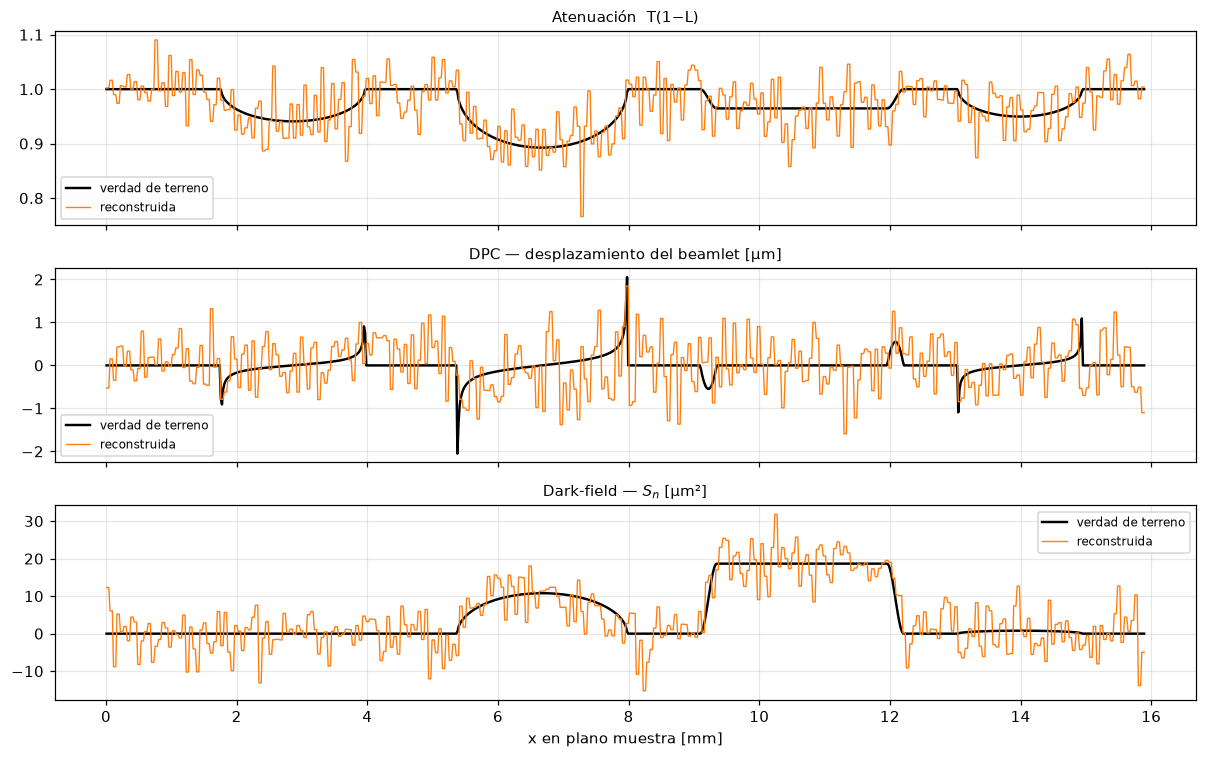

In [7]:
# Validación cuantitativa: perfiles de la fila central
row = cfg.n_rows // 2
x_mm = res.x_pix_um / 1000
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, (attr, key, title) in zip(axes, panels):
    ax.plot(x_mm, res.gt[key][row], 'k-', lw=1.6, label='verdad de terreno')
    ax.plot(x_mm, getattr(out, attr)[row], color='tab:orange', lw=.9, label='reconstruida')
    ax.set_title(title, fontsize=10); ax.grid(alpha=.3); ax.legend(fontsize=8)
axes[-1].set_xlabel('x en plano muestra [mm]')
plt.tight_layout()

## 8. Geometrías personalizadas

Cualquier parámetro es libre: pitches, slit, foco, energía, distancias y offset de la máscara.
Si la geometría no cumple la condición de Moiré nulo, el simulador produce las franjas de Moiré
reales y `validate()` lo advierte. El método `lstsq` usa los coeficientes por píxel
$(W_n, A_n, B_n)$ y tolera desalineamientos moderados.

Configuración        : DF-DPC  (N = 3)
d_sm / d_md / L      : 22.48 / 47.52 / 70.00 cm
Magnificación M      : 3.1132
p_mask / slit        : 53.0 / 20.0 µm (duty 0.38, T_oro 0.09)
p_det / p_eff        : 55.0 / 17.67 µm
Período proyectado   : 165.00 µm (objetivo 165.00 µm, desvío +0.000%)
z_eff                : 15.26 cm
Energía / k          : 40.0 keV / 2.027e+05 µm⁻¹
Foco / penumbra det. : 7.0 / 14.8 µm
Offset máscara       : 17.67 µm (canónico)

Desvío de Moiré: +3.39%


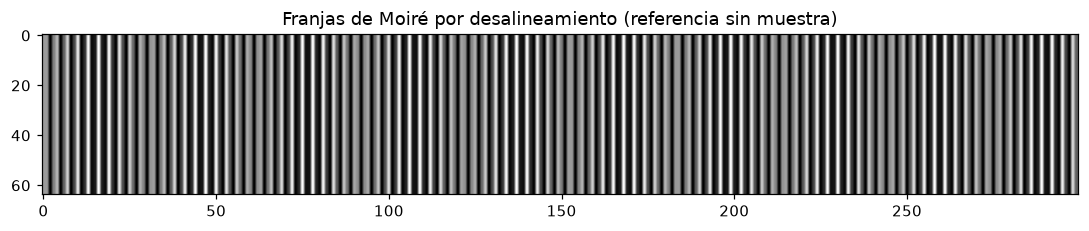

In [8]:
# Ejemplo 1: banco compacto (L = 0.7 m, como el notebook de parámetros de laboratorio)
g_compacto = Geometry.from_total_length(0.70, config='DF-DPC', focal_spot_um=7.0)
print(g_compacto.summary()); g_compacto.validate()
print()

# Ejemplo 2: máscara desalineada un 1% → franjas de Moiré en la referencia
from dataclasses import replace
g_moire = replace(g_compacto, d_md_m=g_compacto.d_md_m * 1.05)
print(f'Desvío de Moiré: {g_moire.moire_mismatch*100:+.2f}%')
res_m = simulate(g_moire, None, SimConfig(n_pix_x=300, n_rows=64, add_noise=False))
fig, ax = plt.subplots(figsize=(10, 2.2))
ax.imshow(res_m.I_mask, cmap='gray', aspect='auto')
ax.set_title('Franjas de Moiré por desalineamiento (referencia sin muestra)')
plt.tight_layout()

## Referencias y unidades

* $D_n$ [µm] — desplazamiento del beamlet en el plano del detector referido al plano muestra;
  ángulo de refracción $\theta = D_n / z_{eff}$ (µrad).
* $S_n$ [µm²] — semivarianza del ensanchamiento del beamlet: $S_n = \tfrac12\sigma_\theta^2 z_{eff}^2$.
* La señal dark-field adimensional del paper es $(\alpha_3/\alpha_1)\,S_n \in [0, 1]$.
* `notebooks/single_mask_df_dpc_params.ipynb` contiene la calculadora de parámetros de
  laboratorio (rangos de distancias, slit óptimo, dithering) complementaria a este framework.
